# Phase 4: Step 1 – Load Cleaned Data + Compute Regression Targets (FD003)

### Step 1A – Load FD003 Clustered Data
We load corrected_clustered_train_FD003.csv which includes:

Engine cycle data

3 operational settings + 21 sensors

Final degradation stage (final_stage) 

In [1]:
import pandas as pd
import numpy as np
import os

# Define base path (two levels up from notebooks/phase4)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Construct full path to clustered dataset
data_file = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD003.csv')

# Load into DataFrame
df = pd.read_csv(data_file)

print("Loaded FD003 data:")
print(df.head())


Loaded FD003 data:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0005        0.0004         100.0  0.355972  0.370523   
1     1     2        0.0008       -0.0003         100.0  0.388759  0.399100   
2     1     3       -0.0014       -0.0002         100.0  0.313817  0.353298   
3     1     4       -0.0020        0.0001         100.0  0.487119  0.417107   
4     1     5        0.0016        0.0000         100.0  0.196721  0.476218   

   sensor_4  sensor_6  sensor_7  ...  sensor_21  kmeans_cluster  \
0  0.308580       1.0  0.208812  ...   0.446331               4   
1  0.309360       1.0  0.236590  ...   0.534836               4   
2  0.445398       1.0  0.230843  ...   0.458577               4   
3  0.237285       1.0  0.268199  ...   0.391966               4   
4  0.321217       1.0  0.245690  ...   0.543371               2   

   agglo_cluster  kmeans_stage  agglo_stage     pca_1     pca_2     tsne_1  \
0              2       St

###  Step 1B: Sort Data by Engine (unit) and Time (cycle)
To compute degradation transitions accurately, we must ensure all cycles for a given engine appear in chronological order.

In [2]:
# Sort cycles in temporal order per engine
df = df.sort_values(by=['unit', 'time']).reset_index(drop=True)

### Step 1C: Add Placeholder Column for Regression Target
Create a new column cycles_to_next_stage, which will be filled in the next step. Initially set to NaN.

In [3]:
# Add empty target column to fill next
df['cycles_to_next_stage'] = np.nan

### Step 1D: Compute cycles_to_next_stage for Each Row
Loop over each engine individually and check how far ahead the next final_stage change occurs.
This helps assign a regression label that tells:
“In how many cycles does the next degradation stage begin?”

In [4]:
# Loop over each engine to compute regression label
engine_ids = df['unit'].unique()

for engine_id in engine_ids:
    engine_df = df[df['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()

    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]

        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break

        # If no stage change till end of life, leave as NaN
        if not found:
            df.loc[indices[i], 'cycles_to_next_stage'] = np.nan


###  Step 1E: Preview the Computed Regression Targets
This shows a few rows with the computed value of cycles_to_next_stage alongside each engine's stage and cycle time.

In [5]:
# View first few results
print("\n Preview of computed regression target:")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head(20))



 Preview of computed regression target:
    unit  time final_stage  cycles_to_next_stage
0      1     1     Stage 4                   4.0
1      1     2     Stage 4                   3.0
2      1     3     Stage 4                   2.0
3      1     4     Stage 4                   1.0
4      1     5     Stage 2                   1.0
5      1     6     Stage 4                  31.0
6      1     7     Stage 4                  30.0
7      1     8     Stage 4                  29.0
8      1     9     Stage 4                  28.0
9      1    10     Stage 4                  27.0
10     1    11     Stage 4                  26.0
11     1    12     Stage 4                  25.0
12     1    13     Stage 4                  24.0
13     1    14     Stage 4                  23.0
14     1    15     Stage 4                  22.0
15     1    16     Stage 4                  21.0
16     1    17     Stage 4                  20.0
17     1    18     Stage 4                  19.0
18     1    19     Stage 4  

### Step 1F: Save the Output and Perform Sanity Checks
We now save the enriched dataset and verify:

Total number of records

How many rows still have NaN regression labels (typically the final cycles per engine)

In [6]:
# Define output path
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD003.csv')

# Save enriched file
df.to_csv(output_path, index=False)
print(f"\n Saved FD003 with regression labels to: {output_path}")

# Sanity diagnostics
print(" Total rows:", len(df))
print(" Missing labels (NaN):", df['cycles_to_next_stage'].isna().sum())



 Saved FD003 with regression labels to: c:\Users\pandr\hybrid-predictive-maintenance\data\regression_train_FD003.csv
 Total rows: 24720
 Missing labels (NaN): 6553


---
#  Step 2 – Feature Selection + Train-Test Split (FD003)
In this step, we:

Load the enriched FD003 regression dataset (regression_train_FD003.csv).

Drop rows with NaN in the target (cycles_to_next_stage).

Select finalized top sensors based on prior phase (Phase 2.5).

Perform engine-level stratified 80:20 train-test split (no leakage).

Output all required variables for model training: X_train, y_train, X_test, y_test.



### Step 2A: Load Regression-Labeled FD003 Data

In [7]:
import pandas as pd

# Load enriched regression-labeled dataset
df = pd.read_csv("../../data/regression_train_FD003.csv")

# Drop rows where regression target is NaN (usually end-of-life or no next stage)
df = df.dropna(subset=["cycles_to_next_stage"]).reset_index(drop=True)

# Shape check
print(f"Dataset shape after dropping NaNs: {df.shape}")
df.head()

Dataset shape after dropping NaNs: (18167, 31)


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage,cycles_to_next_stage
0,1,1,-0.0005,0.0004,100.0,0.355972,0.370523,0.308580,1.0,0.208812,...,4,2,Stage 4,Stage 2,-0.188882,-0.102427,-33.269030,-7.125171,Stage 4,4.0
1,1,2,0.0008,-0.0003,100.0,0.388759,0.399100,0.309360,1.0,0.236590,...,4,2,Stage 4,Stage 2,-0.143457,-0.066518,-8.921116,-1.711969,Stage 4,3.0
2,1,3,-0.0014,-0.0002,100.0,0.313817,0.353298,0.445398,1.0,0.230843,...,4,2,Stage 4,Stage 2,-0.173302,-0.062061,-38.941288,2.529594,Stage 4,2.0
3,1,4,-0.0020,0.0001,100.0,0.487119,0.417107,0.237285,1.0,0.268199,...,4,2,Stage 4,Stage 2,-0.126935,-0.055191,-9.974409,10.897737,Stage 4,1.0
4,1,5,0.0016,0.0000,100.0,0.196721,0.476218,0.321217,1.0,0.245690,...,2,2,Stage 2,Stage 2,-0.093669,-0.189097,4.310718,-8.701614,Stage 2,1.0


### Step 2B: Define Feature Set and Regression Target

In [8]:
# Finalized top sensors from Phase 2.5 (FD003)
features = ['sensor_11', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_4']
target = 'cycles_to_next_stage'

# Input and output variables
X = df[features]
y = df[target]

# Sanity check
print("Input shape:", X.shape)
print("Target shape:", y.shape)
X.describe()

Input shape: (18167, 5)
Target shape: (18167,)


,sensor_11,sensor_12,sensor_7,sensor_17,sensor_4
count,18167.000000,18167.000000,18167.000000,18167.000000,18167.000000
mean,0.338975,0.270327,0.268124,0.353313,0.360611
std,0.112520,0.125459,0.124391,0.121151,0.100754
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.257143,0.195619,0.192529,0.272727,0.288612
50%,0.331429,0.231788,0.230843,0.363636,0.354914
75%,0.411429,0.326032,0.324234,0.454545,0.426833
max,0.760000,0.719307,0.727969,0.818182,0.747582


###  Step 2C: Stratified Train-Test Split by Engine Unit
We ensure no cycle-level leakage by splitting data based on unique engine unit IDs. Stratification is done using each unit's first degradation stage to retain representative diversity.

In [9]:
from sklearn.model_selection import train_test_split

# Get list of unique engine units
units = df['unit'].unique()

# Map unit ID to its first recorded degradation stage for stratification
unit_stage_map = df.groupby('unit')['final_stage'].first()

# Perform stratified split
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    stratify=unit_stage_map,
    random_state=42
)

# Split the full dataset
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df  = df[df['unit'].isin(test_units)].reset_index(drop=True)

# Final input/target splits
X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]

# Report split info
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (14448, 5), Test shape: (3719, 5)


###  Step 2D: Engine Coverage Sanity Check

In [10]:
print("Train engine count:", train_df['unit'].nunique())
print("Test engine count :", test_df['unit'].nunique())

Train engine count: 78
Test engine count : 20


---
# Step 3 – Random Forest Regressor (FD003)

### Step 3A – Import Required Libraries
We import model, metrics, plotting tools, and joblib for model saving.

In [11]:
# Core Modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Utilities
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os


### Step 3B – Initialize and Train Random Forest Regressor
We instantiate the Random Forest with controlled depth and train it using FD003 training data.

In [12]:
# Initialize the model
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train on FD003
rf_regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

###  Step 3C – Predict and Evaluate on Test Set
We evaluate the model using standard regression metrics.

In [13]:
# Predict on test data
y_pred_rf = rf_regressor.predict(X_test)

# Evaluation metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Display results
print(" Random Forest Evaluation Metrics (FD003):")
print(f" RMSE: {rmse_rf:.2f}")
print(f" MAE : {mae_rf:.2f}")
print(f" R²  : {r2_rf:.4f}")


 Random Forest Evaluation Metrics (FD003):
 RMSE: 37.45
 MAE : 24.77
 R²  : 0.6605


#### STEP 3C-1: Random Forest Cross-Validation & Metrics

In [14]:
from sklearn.model_selection import cross_val_score, KFold

# Cross-validation for Random Forest (FD003)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse_rf = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv)
cv_mae_rf  = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv)
cv_r2_rf   =  cross_val_score(rf_regressor, X_train, y_train, scoring='r2', cv=cv)

print("\nCross-Validation Evaluation (Random Forest – FD003):")
print(f"CV RMSE: {cv_rmse_rf.mean():.2f} ± {cv_rmse_rf.std():.2f}")
print(f"CV MAE : {cv_mae_rf.mean():.2f} ± {cv_mae_rf.std():.2f}")
print(f"CV R²  : {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}")



Cross-Validation Evaluation (Random Forest – FD003):
CV RMSE: 34.96 ± 1.23
CV MAE : 20.96 ± 0.60
CV R²  : 0.6385 ± 0.0109


###  Step 3D – Plot: Predicted vs Actual
A scatter plot to visually assess prediction accuracy. Ideal model → points near red line

 Prediction plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_pred_vs_actual_fd003.png


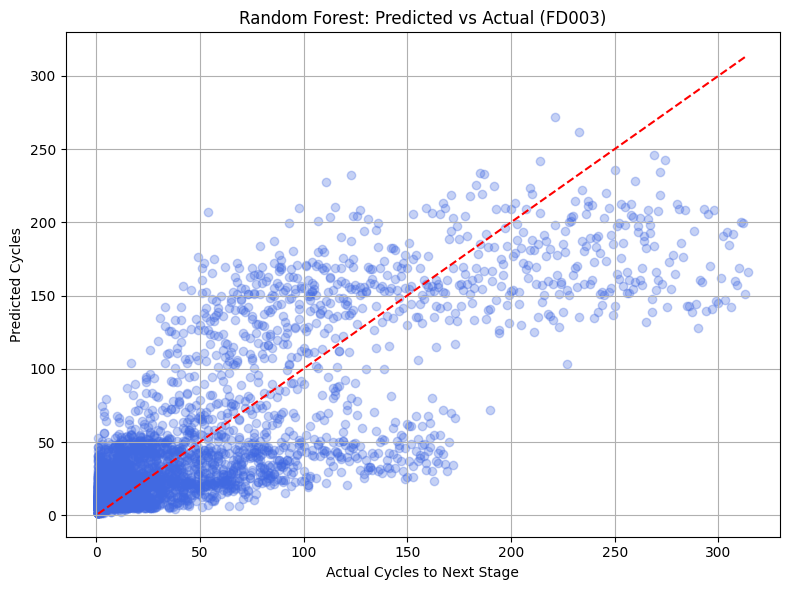

In [15]:
# Plot setup
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Random Forest: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_pred_vs_actual_fd003.png'))
plt.savefig(fig_path)
print(f" Prediction plot saved to: {fig_path}")
plt.show()


### Step 3E – Save Trained Random Forest Model
We save the trained model using joblib for reuse in Step 9 ensemble or deployment.

In [16]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'rf_regressor_fd003.pkl'))
joblib.dump(rf_regressor, model_path)
print(f" Model saved to: {model_path}")


 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd003.pkl


###  Step 3F – Plot: Feature Importances
This explains which features the model relied on most for its predictions

 Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_feature_importance_fd003.png


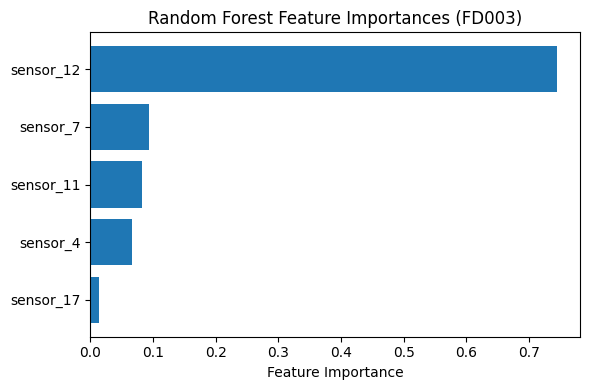

In [17]:
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(X_train.columns)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(X_train.columns)), [X_train.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (FD003)")
plt.tight_layout()

# Save plot
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_feature_importance_fd003.png'))
plt.savefig(feat_imp_path)
print(f" Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
# Step 4 – Ridge Regression for FD003

### Step 4A – Import Required Libraries for Ridge Regression
We import Ridge model, performance metrics (RMSE, MAE, R²), and supporting libraries for visualization and saving artifacts.

In [18]:
# Ridge Regression for FD003

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


### Step 4B – Initialize and Train Ridge Model
Ridge helps stabilize predictions when features are correlated (as in sensor data). Alpha = 1.0 applies mild regularization.


In [19]:
# Initialize Ridge regression with L2 regularization
ridge_regressor = Ridge(alpha=1.0, random_state=42)

# Train on FD003's selected features
ridge_regressor.fit(X_train, y_train)

Ridge(random_state=42)

### Step 4C – Predict and Evaluate Ridge Model

In [20]:
# Make predictions
y_pred_ridge = ridge_regressor.predict(X_test)

# Evaluate
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Evaluation Metrics (FD003):")
print(f" RMSE: {rmse_ridge:.2f}")
print(f" MAE : {mae_ridge:.2f}")
print(f" R²  : {r2_ridge:.4f}")


Ridge Regression Evaluation Metrics (FD003):
 RMSE: 56.11
 MAE : 38.75
 R²  : 0.2379


#### Step 4C-1 CV for Ridge Regression – FD003

In [21]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

ridge_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))

cv_rmse_ridge = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_ridge  = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_ridge   =  cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (Ridge Regression – FD003):")
print(f"CV RMSE: {cv_rmse_ridge.mean():.2f} ± {cv_rmse_ridge.std():.2f}")
print(f"CV MAE : {cv_mae_ridge.mean():.2f} ± {cv_mae_ridge.std():.2f}")
print(f"CV R²  : {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}")



Cross-Validation Evaluation (Ridge Regression – FD003):
CV RMSE: 51.10 ± 12.61
CV MAE : 36.95 ± 4.74
CV R²  : -0.0385 ± 0.4177


### Step 4D – Plot: Predicted vs Actual
Visual check: Points close to red line = good model. Helps spot bias or underfitting.

Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_pred_vs_actual_fd003.png


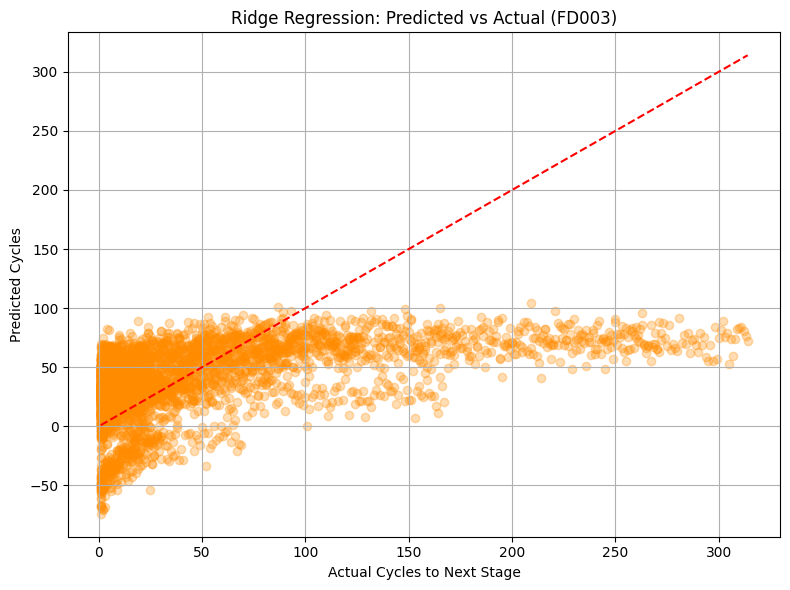

In [22]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Ridge Regression: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()

# Save figure
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_pred_vs_actual_fd003.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


###  Step 4E – Save Trained Ridge Model
Stores model for later use or ensemble averaging.

In [23]:
# Save model
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'ridge_regressor_fd003.pkl'))
joblib.dump(ridge_regressor, model_path)
print(f"Model saved to: {model_path}")

Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\ridge_regressor_fd003.pkl


### Step 4F – Plot Coefficient Magnitudes
In Ridge, coefficients indicate feature impact on predictions. Useful for interpretation.

Feature coefficient plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_feature_coefficients_fd003.png


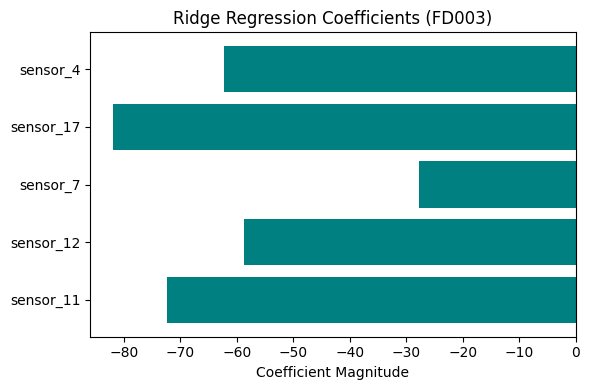

In [24]:
# Coefficient bar plot
coefs = ridge_regressor.coef_
features = X_train.columns

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), coefs, align='center', color='teal')
plt.yticks(range(len(features)), features)
plt.xlabel("Coefficient Magnitude")
plt.title("Ridge Regression Coefficients (FD003)")
plt.tight_layout()

# Save plot
coef_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_feature_coefficients_fd003.png'))
plt.savefig(coef_path)
print(f"Feature coefficient plot saved to: {coef_path}")
plt.show()


---
# Step 5: Model 3 – Support Vector Regressor (SVR) Evaluation (FD003)
Support Vector Regression is a non-linear regression technique that fits data within an epsilon margin of tolerance. It uses kernels to handle complex relationships and works well with high-dimensional data. It's less interpretable but offers robust predictions on mid-range values.

### Step 5A: Import Libraries

In [25]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


### 5B: Initialize + Train SVR Model


In [26]:
svr_regressor_fd003 = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10.0, epsilon=0.2)
)

svr_regressor_fd003.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=10.0, epsilon=0.2))])

### 5C: Predict + Evaluate

In [27]:
# Make predictions on test data
y_pred_svr_fd003 = svr_regressor_fd003.predict(X_test)

# Compute evaluation metrics
rmse_svr_fd003 = np.sqrt(mean_squared_error(y_test, y_pred_svr_fd003))
mae_svr_fd003 = mean_absolute_error(y_test, y_pred_svr_fd003)
r2_svr_fd003 = r2_score(y_test, y_pred_svr_fd003)

# Print results
print(" SVR Evaluation Metrics (FD003):")
print(f" RMSE: {rmse_svr_fd003:.2f}")
print(f" MAE : {mae_svr_fd003:.2f}")
print(f" R²  : {r2_svr_fd003:.4f}")


 SVR Evaluation Metrics (FD003):
 RMSE: 38.83
 MAE : 23.72
 R²  : 0.6351


#### Step 5C-1 Cross-Validation for FD003 – SVR

In [28]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

svr_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.2))

cv_rmse_svr = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_svr  = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_svr   =  cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (SVR – FD003):")
print(f"CV RMSE: {cv_rmse_svr.mean():.2f} ± {cv_rmse_svr.std():.2f}")
print(f"CV MAE : {cv_mae_svr.mean():.2f} ± {cv_mae_svr.std():.2f}")
print(f"CV R²  : {cv_r2_svr.mean():.4f} ± {cv_r2_svr.std():.4f}")



Cross-Validation Evaluation (SVR – FD003):
CV RMSE: 37.38 ± 11.48
CV MAE : 21.14 ± 5.57
CV R²  : 0.4840 ± 0.1247


### Step 5D: Plot – Predicted vs Actual
This plot shows prediction quality. The red dashed line is the ideal (perfect prediction).

Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\svr_pred_vs_actual_fd003.png


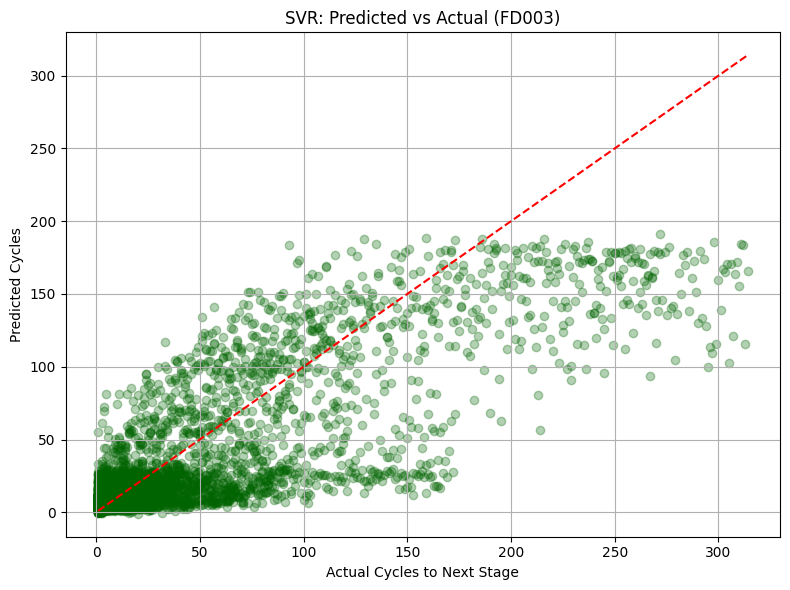

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr_fd003, alpha=0.3, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("SVR: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()

# Save figure
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'svr_pred_vs_actual_fd003.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


### Step 5E: Save Trained SVR Model

In [30]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'svr_regressor_fd003.pkl'))
joblib.dump(svr_regressor_fd003, model_path)
print(f"Model saved to: {model_path}")

Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\svr_regressor_fd003.pkl


### Step 5F: Feature Importance

In [31]:
print("SVR does not expose feature importances or coefficients.")

SVR does not expose feature importances or coefficients.


---
# Step 6: Model 4 – XGBoost Regressor (FD003)
XGBoost is a powerful ensemble tree-based model that excels in handling complex non-linear relationships and missing values. It’s known for high accuracy and speed, and is widely used in production systems for structured data.

### Step 6A: Import Required Libraries

In [32]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 6B – Initialize and Train

In [33]:
xgb_regressor_fd003 = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_regressor_fd003.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

### Step 6C: Predict and Evaluate

In [34]:
# Step 6C: Predict and Evaluate
y_pred_xgb = xgb_regressor_fd003.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Evaluation Metrics (FD003):")
print(f" RMSE: {rmse_xgb:.2f}")
print(f" MAE : {mae_xgb:.2f}")
print(f" R²  : {r2_xgb:.4f}")


XGBoost Evaluation Metrics (FD003):
 RMSE: 37.82
 MAE : 24.92
 R²  : 0.6538


#### Step 6C-1 Cross-Validation for FD003 – XGBoost

In [35]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

xgb_cv = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_rmse_xgb = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_xgb  = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_xgb   =  cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (XGBoost – FD003):")
print(f"CV RMSE: {cv_rmse_xgb.mean():.2f} ± {cv_rmse_xgb.std():.2f}")
print(f"CV MAE : {cv_mae_xgb.mean():.2f} ± {cv_mae_xgb.std():.2f}")
print(f"CV R²  : {cv_r2_xgb.mean():.4f} ± {cv_r2_xgb.std():.4f}")



Cross-Validation Evaluation (XGBoost – FD003):
CV RMSE: 36.39 ± 9.86
CV MAE : 22.04 ± 4.80
CV R²  : 0.4923 ± 0.1642


### Step 6D: Predicted vs Actual Plot

Prediction plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_pred_vs_actual_fd003.png


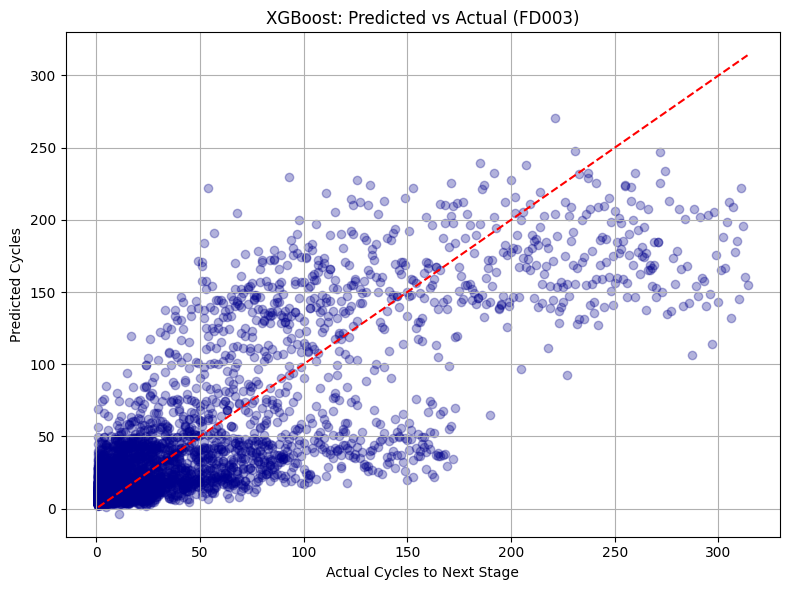

In [36]:
# Step 6D: Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("XGBoost: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()

# Save the plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_pred_vs_actual_fd003.png'))
plt.savefig(fig_path)
print(f"Prediction plot saved to: {fig_path}")
plt.show()

### Step 6E: Save the Model

In [37]:
# Step 6E: Save the Model
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'xgb_regressor_fd003.pkl'))
joblib.dump(xgb_regressor_fd003, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\xgb_regressor_fd003.pkl


### Step 6F: Feature Importance Plot

Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_feature_importance_fd003.png


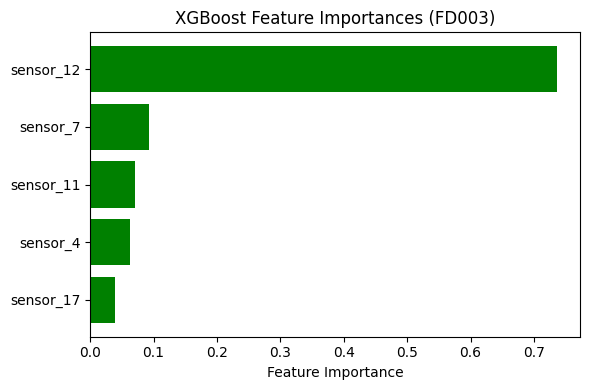

In [ ]:
# Step 6F: Feature Importance Plot
importances = xgb_regressor_fd003.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(X_train.columns)), [importances[i] for i in sorted_idx], align='center', color='green')
plt.yticks(range(len(X_train.columns)), [X_train.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances (FD003)")
plt.tight_layout()

# Save the plot
feat_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_feature_importance_fd003.png'))
plt.savefig(feat_path)
print(f"Feature importance plot saved to: {feat_path}")
plt.show()


---
# Step 7 – Model Comparison (FD003)
This step compares all trained regressors (Random Forest, Ridge, SVR, XGBoost) on FD003 using key metrics to determine the most reliable model for predicting cycles to next degradation stage.



### Step 7A – Define Model Comparison Table and Save CSV

In [39]:
import pandas as pd
import os

# Define Cross-Validation metrics for all models (FD003)
model_results_fd003 = pd.DataFrame({
    'Model': [
        'Random Forest (Tuned)',
        'XGBoost Regressor',
        'Support Vector Regressor',
        'Ridge Regression'
    ],
    'CV RMSE':  [34.96, 36.39, 37.38, 51.10],
    'RMSE ± Std': ['± 1.23', '± 9.86', '± 11.48', '± 12.61'],
    'CV MAE':   [20.96, 22.04, 21.14, 36.95],
    'MAE ± Std': ['± 0.60', '± 4.80', '± 5.57', '± 4.74'],
    'CV R² Score': [0.6385, 0.4923, 0.4840, -0.0385],
    'R² ± Std': ['± 0.0109', '± 0.1642', '± 0.1247', '± 0.4177']
})

# Sort by lowest RMSE
model_results_fd003 = model_results_fd003.sort_values(by='CV RMSE').reset_index(drop=True)

# Save to report directory
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(report_dir, exist_ok=True)
cv_table_path = os.path.join(report_dir, 'model_comparison_cv_fd003.csv')
model_results_fd003.to_csv(cv_table_path, index=False)

# Print and confirm
print(" FD003 Model Comparison (CV Metrics) saved to:")
print(cv_table_path)
print(model_results_fd003)


 FD003 Model Comparison (CV Metrics) saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_fd003.csv
                      Model  CV RMSE RMSE ± Std  CV MAE MAE ± Std  \
0     Random Forest (Tuned)    34.96     ± 1.23   20.96    ± 0.60   
1         XGBoost Regressor    36.39     ± 9.86   22.04    ± 4.80   
2  Support Vector Regressor    37.38    ± 11.48   21.14    ± 5.57   
3          Ridge Regression    51.10    ± 12.61   36.95    ± 4.74   

   CV R² Score  R² ± Std  
0       0.6385  ± 0.0109  
1       0.4923  ± 0.1642  
2       0.4840  ± 0.1247  
3      -0.0385  ± 0.4177  


#### Step 7B – RMSE Comparison Plot

 RMSE comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\../../figures/phase4/model_comparison_rmse_fd003.png


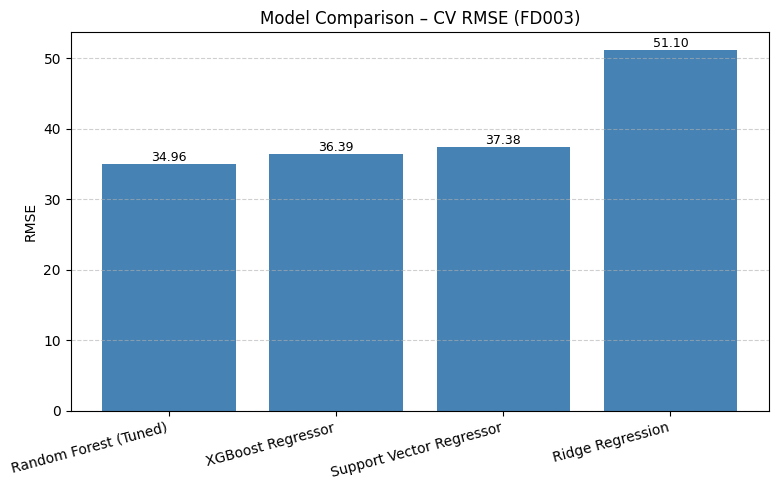

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd003['Model'], model_results_fd003['CV RMSE'], color='steelblue')
plt.title("Model Comparison – CV RMSE (FD003)")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
rmse_plot_path = os.path.join(report_dir, '../../figures/phase4/model_comparison_rmse_fd003.png')
plt.savefig(rmse_plot_path)
print(f" RMSE comparison plot saved to: {rmse_plot_path}")
plt.show()


####  Step 7C – MAE and R² Comparison Plots

 MAE comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\../../figures/phase4/mae_comparison_fd003.png


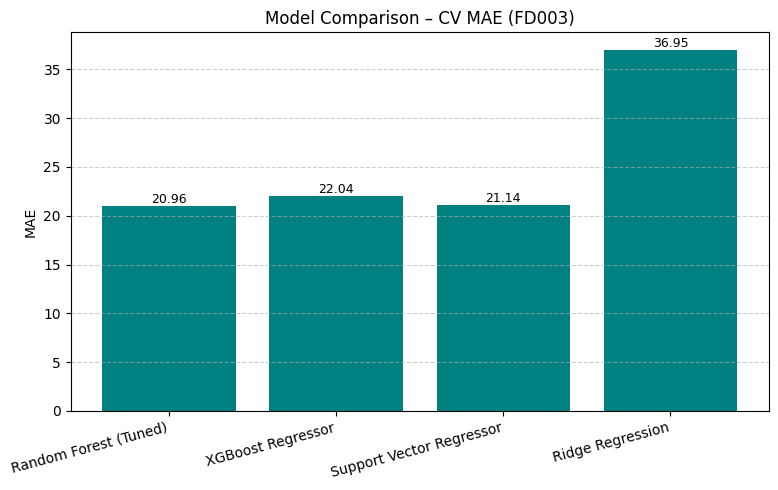

 R² Score comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\../../figures/phase4/r2_comparison_fd003.png


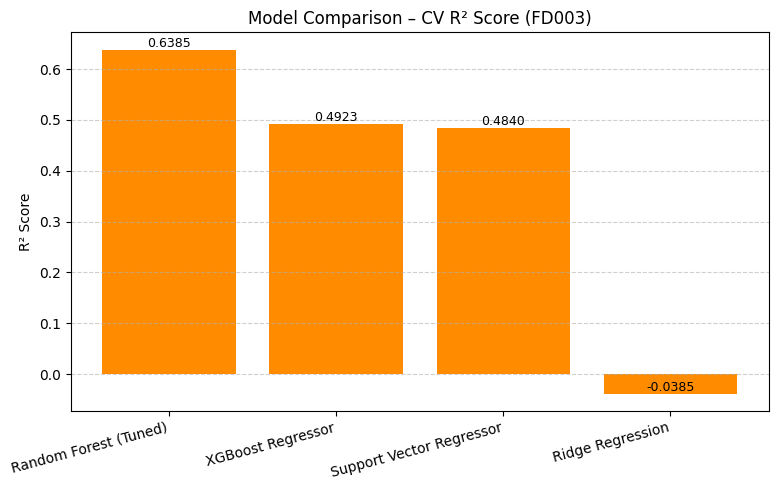

In [41]:
# MAE Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd003['Model'], model_results_fd003['CV MAE'], color='teal')
plt.title("Model Comparison – CV MAE (FD003)")
plt.ylabel("MAE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
mae_path = os.path.join(report_dir, '../../figures/phase4/mae_comparison_fd003.png')
plt.savefig(mae_path)
print(f" MAE comparison plot saved to: {mae_path}")
plt.show()

# R² Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd003['Model'], model_results_fd003['CV R² Score'], color='darkorange')
plt.title("Model Comparison – CV R² Score (FD003)")
plt.ylabel("R² Score")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
r2_path = os.path.join(report_dir, '../../figures/phase4/r2_comparison_fd003.png')
plt.savefig(r2_path)
print(f" R² Score comparison plot saved to: {r2_path}")
plt.show()


---
# Step 8: Residual Analysis – Ensemble and Individual Models (FD003)

#### Step 8A: Import Required Libraries

In [42]:
# Step 8A: Import Required Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


#### Step 8B: Compute Residuals for All Models (FD003)

In [44]:

# Compute residuals: Actual - Predicted
residuals = {
    "Random Forest": y_test - y_pred_rf,
    "Ridge Regression": y_test - y_pred_ridge,
    "SVR": y_test - y_pred_svr_fd003,
    "XGBoost": y_test - y_pred_xgb
}


####  Step 8C – Plot Residual Distributions (FD003)

Residual distribution plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_fd003.png


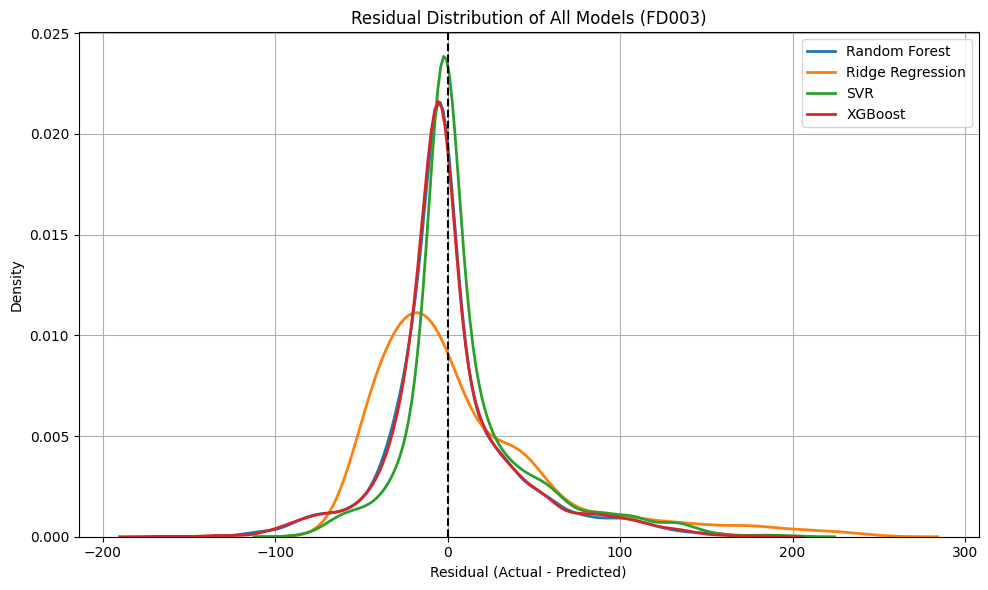

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))
for model_name, res in residuals.items():
    sns.kdeplot(res, label=model_name, linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution of All Models (FD003)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
residual_dist_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_fd003.png'))
plt.savefig(residual_dist_path)
print(f"Residual distribution plot saved to: {residual_dist_path}")
plt.show()


#### Step 8D – Residuals vs Predicted (FD003)

Residual vs predicted plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_fd003.png


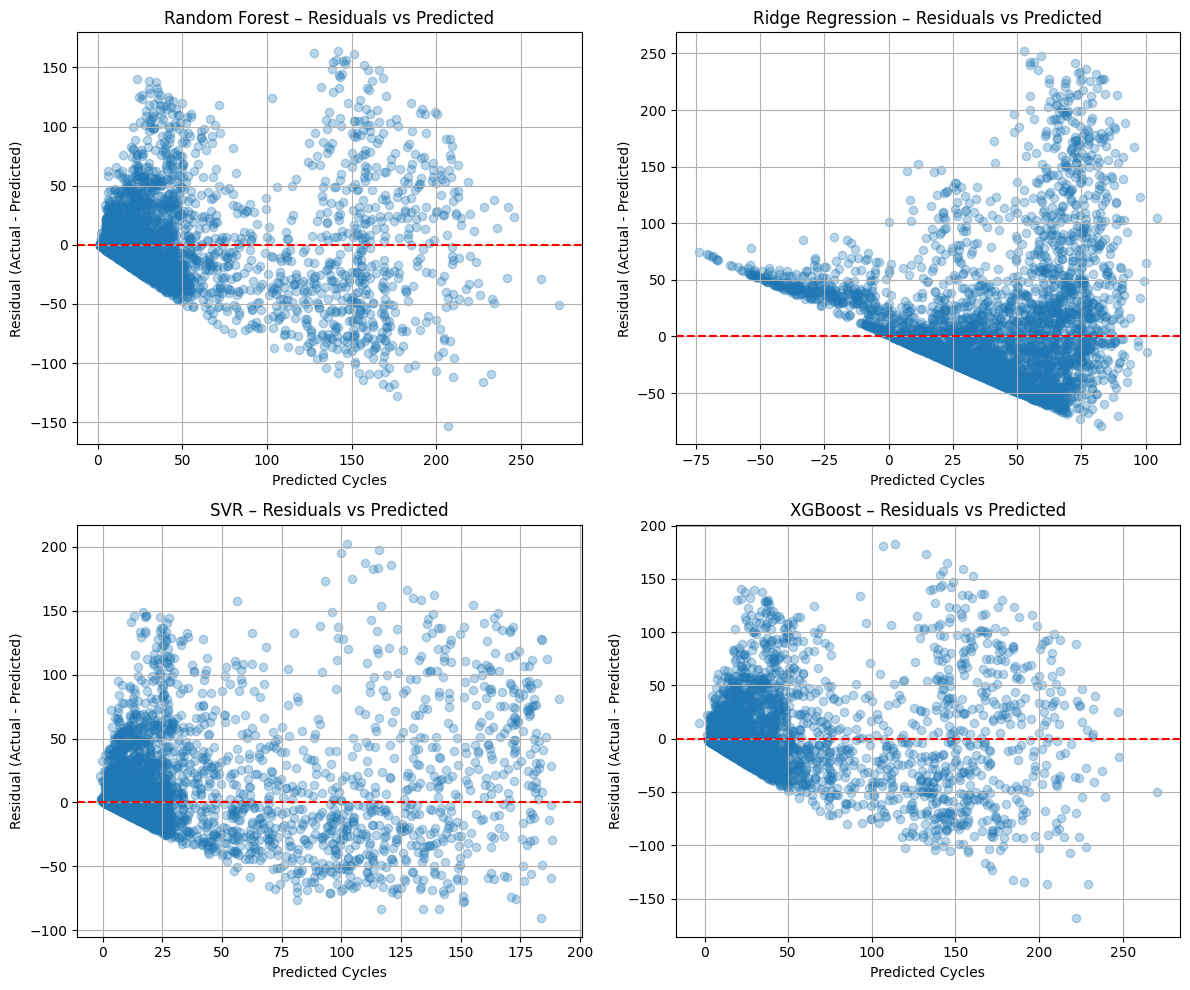

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
model_preds = {
    "Random Forest": y_pred_rf,
    "Ridge Regression": y_pred_ridge,
    "SVR": y_pred_svr_fd003,
    "XGBoost": y_pred_xgb
}

for ax, (model_name, pred) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(pred, residuals[model_name], alpha=0.3)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f"{model_name} – Residuals vs Predicted")
    ax.set_xlabel("Predicted Cycles")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(True)

plt.tight_layout()
residual_vs_pred_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_fd003.png'))
plt.savefig(residual_vs_pred_path)
print(f"Residual vs predicted plot saved to: {residual_vs_pred_path}")
plt.show()


---
# Step 9 – Weighted Ensemble Averaging (FD003)

####  Step 9A – Import Required Libraries

In [48]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os
import pandas as pd


#### Step 9B – Weighted Ensemble Averaging (FD003)

In [49]:
# Cross-validated RMSE values from Step 7 table
rmse_values = {
    'rf': 34.96,
    'ridge': 51.10,
    'svr': 37.38,
    'xgb': 36.39
}

# Compute inverse-RMSE weights
inv_rmse = {k: 1/v for k, v in rmse_values.items()}
total_inv = sum(inv_rmse.values())
weights = {k: v / total_inv for k, v in inv_rmse.items()}

print("Model Weights (Inverse RMSE – FD003):")
for model, weight in weights.items():
    print(f"{model.upper()} weight: {weight:.4f}")

# Weighted average predictions
y_pred_ensemble_fd003 = (
    weights['rf']   * y_pred_rf +
    weights['ridge'] * y_pred_ridge +
    weights['svr']  * y_pred_svr_fd003 +
    weights['xgb']  * y_pred_xgb
)


Model Weights (Inverse RMSE – FD003):
RF weight: 0.2793
RIDGE weight: 0.1911
SVR weight: 0.2612
XGB weight: 0.2683


#### Step 9C – Evaluate Ensemble Performance

In [50]:
rmse_ens_fd003 = np.sqrt(mean_squared_error(y_test, y_pred_ensemble_fd003))
mae_ens_fd003 = mean_absolute_error(y_test, y_pred_ensemble_fd003)
r2_ens_fd003 = r2_score(y_test, y_pred_ensemble_fd003)

print("\nWeighted Ensemble Evaluation (FD003):")
print(f" RMSE: {rmse_ens_fd003:.2f}")
print(f" MAE : {mae_ens_fd003:.2f}")
print(f" R²  : {r2_ens_fd003:.4f}")



Weighted Ensemble Evaluation (FD003):
 RMSE: 38.25
 MAE : 25.27
 R²  : 0.6458


#### Step 9D – Predicted vs Actual Plot

Saved ensemble prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ensemble_pred_vs_actual_fd003.png


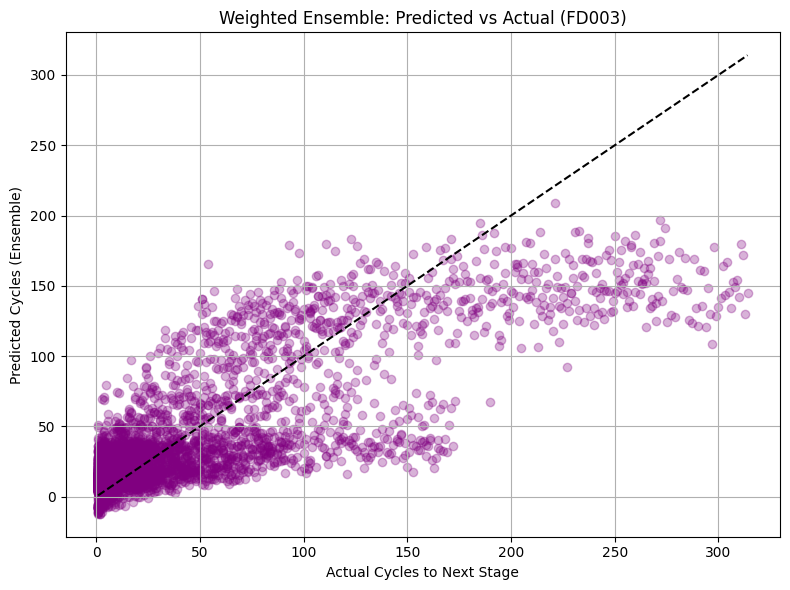

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ensemble_fd003, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles (Ensemble)")
plt.title("Weighted Ensemble: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()

# Save figure
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ensemble_pred_vs_actual_fd003.png'))
plt.savefig(fig_path)
print(f"Saved ensemble prediction plot to: {fig_path}")
plt.show()


#### Step 9E – Update Model Comparison Table

In [52]:
# Paths
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
cv_path = os.path.join(report_dir, 'model_comparison_cv_fd003.csv')
final_path = os.path.join(report_dir, 'model_comparison_cv_with_ensemble_fd003.csv')

# Load existing model comparison
model_results_fd003 = pd.read_csv(cv_path)

# Append ensemble row
ensemble_row = pd.DataFrame({
    'Model': ['Weighted Ensemble (Inv RMSE)'],
    'CV RMSE': [rmse_ens_fd003],
    'RMSE ± Std': ['—'],
    'CV MAE': [mae_ens_fd003],
    'MAE ± Std': ['—'],
    'CV R² Score': [r2_ens_fd003],
    'R² ± Std': ['—']
})

model_results_fd003 = pd.concat([model_results_fd003, ensemble_row], ignore_index=True)
model_results_fd003 = model_results_fd003.sort_values(by='CV RMSE').reset_index(drop=True)

# Save updated table
model_results_fd003.to_csv(final_path, index=False)

print(" Final model comparison with ensemble saved to:")
print(final_path)
print(model_results_fd003)


 Final model comparison with ensemble saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_with_ensemble_fd003.csv
                          Model    CV RMSE RMSE ± Std     CV MAE MAE ± Std  \
0         Random Forest (Tuned)  34.960000     ± 1.23  20.960000    ± 0.60   
1             XGBoost Regressor  36.390000     ± 9.86  22.040000    ± 4.80   
2      Support Vector Regressor  37.380000    ± 11.48  21.140000    ± 5.57   
3  Weighted Ensemble (Inv RMSE)  38.254208          —  25.266368         —   
4              Ridge Regression  51.100000    ± 12.61  36.950000    ± 4.74   

   CV R² Score  R² ± Std  
0     0.638500  ± 0.0109  
1     0.492300  ± 0.1642  
2     0.484000  ± 0.1247  
3     0.645756         —  
4    -0.038500  ± 0.4177  


---
# Step 10 – Residual Analysis for Ensemble Averaging (FD003)

####  Step 10A: Residual Distribution Plot – Weighted Ensemble

Residual distribution plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_weighted_ensemble_fd003.png


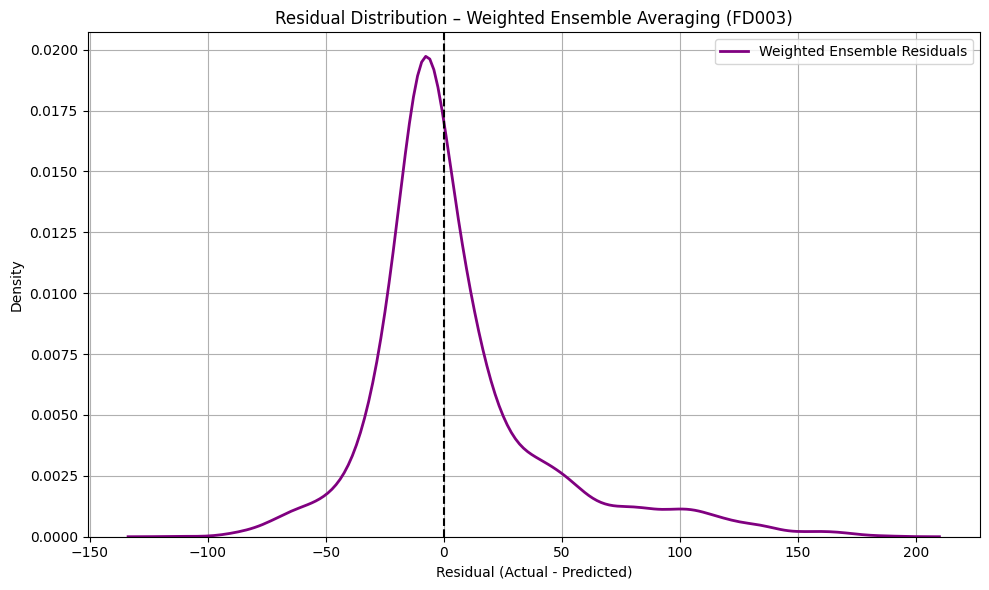

In [53]:
# Compute residuals for weighted ensemble
residuals_weighted_fd003 = y_test - y_pred_ensemble_fd003

# Plot residual distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_weighted_fd003, color='purple', linewidth=2, label="Weighted Ensemble Residuals")
plt.axvline(0, linestyle='--', color='black')
plt.title("Residual Distribution – Weighted Ensemble Averaging (FD003)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_weighted_ensemble_fd003.png'))
plt.savefig(fig_path)
print(f"Residual distribution plot saved to: {fig_path}")
plt.show()


#### Step 10B: Residuals vs Predicted Plot – Weighted Ensemble

Residual vs predicted plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_weighted_ensemble_fd003.png


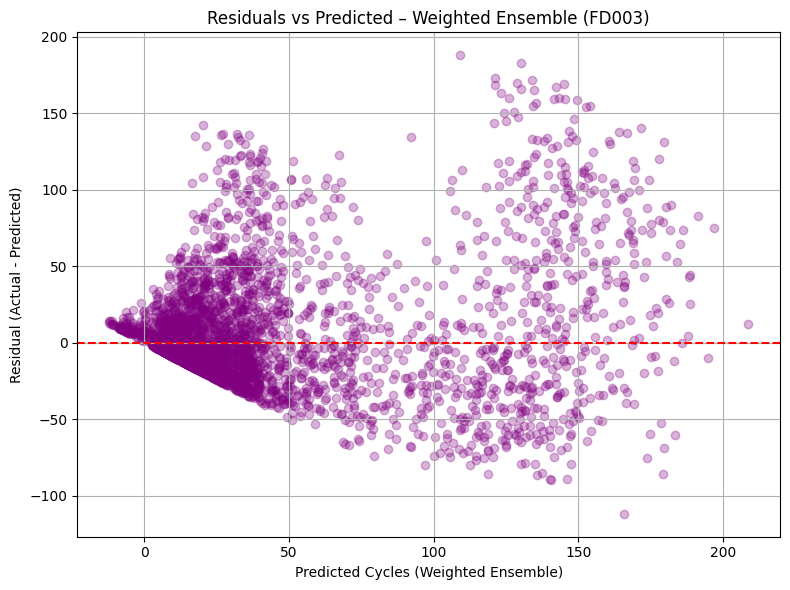

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_ensemble_fd003, residuals_weighted_fd003, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Cycles (Weighted Ensemble)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted – Weighted Ensemble (FD003)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path2 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_weighted_ensemble_fd003.png'))
plt.savefig(fig_path2)
print(f"Residual vs predicted plot saved to: {fig_path2}")
plt.show()

---
# FD003 – Save Final Predictions + Ensemble Outputs

In [55]:
import os
import pandas as pd

# Set correct save path
save_path_fd003 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(save_path_fd003, exist_ok=True)

# Construct DataFrame with all predictions
final_df_fd003 = pd.DataFrame({
    'unit': test_df['unit'],
    'time': test_df['time'],
    'actual_cycles_to_next_stage': y_test,
    'random_forest_prediction': y_pred_rf,
    'ridge_prediction': y_pred_ridge,
    'svr_prediction': y_pred_svr_fd003,
    'xgboost_prediction': y_pred_xgb,
    'weighted_ensemble_prediction': y_pred_ensemble_fd003
})

# Save to CSV
fd003_csv_path = os.path.join(save_path_fd003, 'final_predictions_fd003.csv')
final_df_fd003.to_csv(fd003_csv_path, index=False)

print(f"FD003 predictions saved to: {fd003_csv_path}")


FD003 predictions saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\final_predictions_fd003.csv
